<a href="https://colab.research.google.com/github/Meenakshimadhu192001/Case_study/blob/main/heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##importing Libraries

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [59]:
file_path ='/content/heart_disease (3).csv'
df_heart =pd.read_csv(file_path)
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [60]:
df_heart.shape

(1025, 14)

In [61]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [62]:
df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [63]:
df_heart.isnull().sum() #checking missing value

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [64]:
df_heart.duplicated().sum()

np.int64(723)

In [65]:
#if duplicate excist drop
df = df_heart.drop_duplicates()

##checking numerical columns and categorical columns

In [66]:
cat_cols =['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
cat_cols

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

##Outlier detection

In [67]:
Q1=df_heart[col].quantile(0.25)
Q3=df_heart[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outlier =df_heart[(df_heart[col]<lower_bound) | (df_heart[col]<upper_bound)]
print(f"{col}:{len(outlier)}outliers")

target:1025outliers


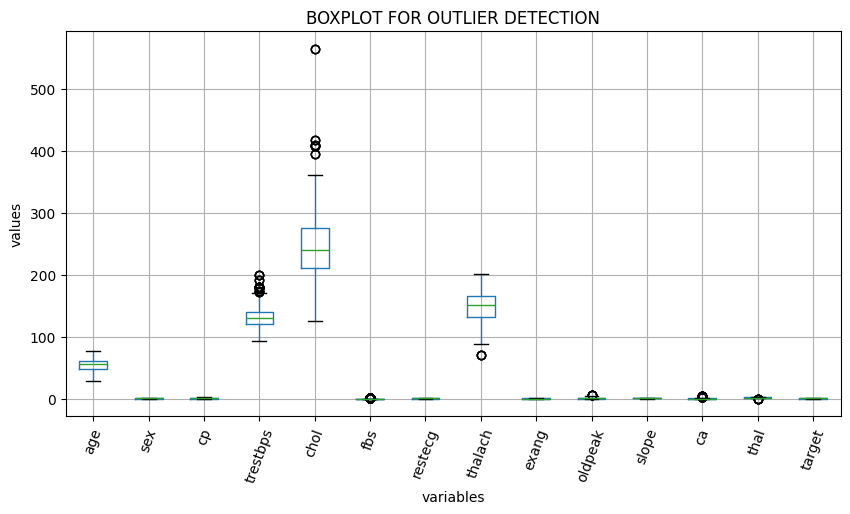

In [68]:
#boxplot
plt.figure(figsize=(10,5))
df_heart.boxplot(rot=70) #rotation of below text
plt.title('BOXPLOT FOR OUTLIER DETECTION')
plt.xlabel('variables')
plt.ylabel('values')
plt.show()

In [69]:
#removing outlier
#removal of outliers
df_heart = df_heart[(df_heart[col]>= lower_bound) & (df_heart[col] <= upper_bound)]
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [70]:
# Histogram
for i in df_heart.select_dtypes(include='object').columns:
  sns.countplot(data=df_heart, x=i)
  plt.show()

In [71]:
#Handle missing values:
 #For numerical columns, use imputation techniques : median/mean
for col in num_cols:
  df_heart[col] =df_heart[col].fillna(df_heart[col].median())
df_heart[col]

,target
0,0
1,0
2,0
3,0
4,0
...,...
1020,1
1021,0
1022,0
1023,1


In [72]:
#Handle missing values:
 #For categorical columns, use imputation techniques : mode
for col in cat_cols:
  df_heart[col] = df_heart[col].fillna( df_heart[col].mode()[0])
  df_heart[col]

In [73]:
#Missing values after imputation
df_heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


##Encoding

In [74]:
 #Binary encoding: sex and fasting blood sugar are already 0/1, no change needed
df_heart["sex"] = df_heart["sex"].astype(int)
df_heart["fbs"] = df_heart["fbs"].astype(int)

In [75]:
#Use one-hot encoding for multi-category variables (chest pain type, resting electrocardiographic results, thal)
print(cat_cols)

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [76]:
feature_cat_cols = (["cp", "restecg", "thal"])

In [77]:
#next step is we are taking unique of each cat
df_heart['cp'].unique()

array([0, 1, 2, 3])

In [78]:
df_heart["restecg"].unique()

array([1, 0, 2])

In [79]:
df_heart[ "thal"].unique()

array([3, 2, 1, 0])

In [80]:
ohe_cols = ["cp", "restecg", "thal"] #ohe
df_heart_ohe = pd.get_dummies(df_heart , columns=ohe_cols , dtype = int)
df_heart_ohe.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,2,...,0,0,0,0,1,0,0,0,0,1
1,53,1,140,203,1,155,1,3.1,0,0,...,0,0,0,1,0,0,0,0,0,1
2,70,1,145,174,0,125,1,2.6,0,0,...,0,0,0,0,1,0,0,0,0,1
3,61,1,148,203,0,161,0,0.0,2,1,...,0,0,0,0,1,0,0,0,0,1
4,62,0,138,294,1,106,0,1.9,1,3,...,0,0,0,0,1,0,0,0,1,0


##Scaling

In [81]:
#Scale these features using techniques like Min-Max scaling or Standard scaling
# object for standard scaling
#Scale features such as resting blood pressure, serum cholesterol, maximum heart rate, and oldpeak using StandardScaler or MinMaxScaler.

scale_cols = ["trestbps", "chol", "thalach", "oldpeak"]
stand_scalar = StandardScaler()
df_heart[num_cols] = stand_scalar.fit_transform(df_heart[num_cols])
df_heart[num_cols]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852,-1.026698
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852,-1.026698
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852,-1.026698
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852,-1.026698
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122,-1.026698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,0.503520,0.661504,0.055931,0.479107,-0.484803,-0.418878,0.891255,0.647366,1.403928,-0.912329,0.995433,-0.731971,-0.522122,0.973997
1021,0.613800,0.661504,-0.915755,-0.377636,0.232705,-0.418878,-1.004049,-0.352873,1.403928,1.471705,-0.624121,0.238625,1.089852,-1.026698
1022,-0.819834,0.661504,-0.915755,-1.234378,0.562371,-0.418878,-1.004049,-1.353113,1.403928,-0.060888,-0.624121,0.238625,-0.522122,-1.026698
1023,-0.488996,-1.511706,-0.915755,-1.234378,0.155137,-0.418878,-1.004049,0.429923,-0.712287,-0.912329,0.995433,-0.731971,-0.522122,0.973997


## Train-Test Split


In [82]:
#Split the data into training and testing sets:
#For Regression: Predict serum cholesterol as the target variable and remaining as features

X_reg = df_heart.drop(columns=["chol"])
y_reg = df_heart["chol"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=43)

print("Regression - Train:", X_train_reg.shape, "Test:", X_test_reg.shape)


Regression - Train: (820, 13) Test: (205, 13)


In [93]:
# --- Classification: target = target (heart disease presence), remaining columns as features ---
X_clf = df_heart.drop(columns=["target"])
y_clf = df_heart["target"]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
print("Classification - Train:", X_clf_train.shape, "Test:", X_clf_test.shape)

Classification - Train: (820, 13) Test: (205, 13)


Step 4: Build Machine Learning Models
Regression Task:

Train the following models to predict serum cholesterol.
 Linear regression
SVM
Random Forest
Classification Task:

Train the following models to predict target:
Logistic Regression
K-Nearest Neighbors (KNN)
Random Fores

In [89]:
#linear regression
# Train model
linear = LinearRegression()
linear.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_linear = linear.predict(X_test_reg)

# Evaluation
print("Linear Regression")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_linear))
print("MSE :", mean_squared_error(y_test_reg, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)))
print("R2 Score:", r2_score(y_test_reg, y_pred_linear))

Linear Regression
MAE : 0.6975273346560271
MSE : 0.7783192948386569
RMSE: 0.882224061584503
R2 Score: 0.07955302974329259


In [90]:
#Train model
svr = SVR(kernel='rbf')
svr.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_svr = svr.predict(X_test_reg)

# Evaluation
print("Support Vector Regression")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_svr))
print("MSE :", mean_squared_error(y_test_reg, y_pred_svr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_svr)))
print("R2 Score:", r2_score(y_test_reg, y_pred_svr))

Support Vector Regression
MAE : 0.4560453923968396
MSE : 0.4444964914489183
RMSE: 0.6667057007772758
R2 Score: 0.47433469585421784


In [91]:
#Random forest
# Train model
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_rf = rf_reg.predict(X_test_reg)

# Evaluation
print("Random Forest Regressor")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_rf))
print("MSE :", mean_squared_error(y_test_reg, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)))
print("R2 Score:", r2_score(y_test_reg, y_pred_rf))

Random Forest Regressor
MAE : 0.14677091756361332
MSE : 0.06791626077258067
RMSE: 0.2606074841070008
R2 Score: 0.919681656520869


In [97]:
#classification :logistic REgression
# Train model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_clf, y_train_clf)

# Prediction
y_pred_log = log_model.predict(X_test_clf)
# Evaluation
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test_clf, y_pred_log))
print("Precision:", precision_score(y_test_clf, y_pred_log))
print("Recall   :", recall_score(y_test_clf, y_pred_log))
print("F1 Score :", f1_score(y_test_clf, y_pred_log))

NameError: name 'X_train_clf' is not defined